In [1]:
import numpy as np
import pandas as pd
import locan as lc
import matplotlib.pyplot as plt
import napari

lc.configuration.N_JOBS = -1

In [61]:
me3_locdata = lc.locan_io.load_thunderstorm_file("test_data/k27_k27_thaw009_me3.csv")
ac_locdata = lc.locan_io.load_thunderstorm_file("test_data/k27_k27_thaw009_ac.csv")

In [78]:
me3_noise, me3_clusters = lc.cluster_dbscan(me3_locdata, eps=20, min_samples=3)
ac_noise, ac_clusters = lc.cluster_dbscan(ac_locdata, eps=20, min_samples=3)

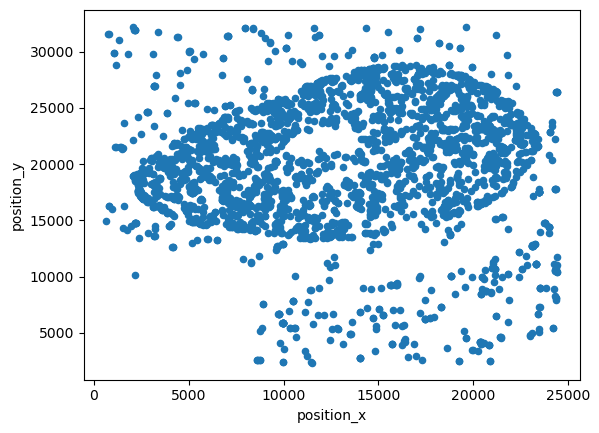

In [79]:
me3_clusters.data.plot.scatter(x='position_x', y='position_y')
plt.show()

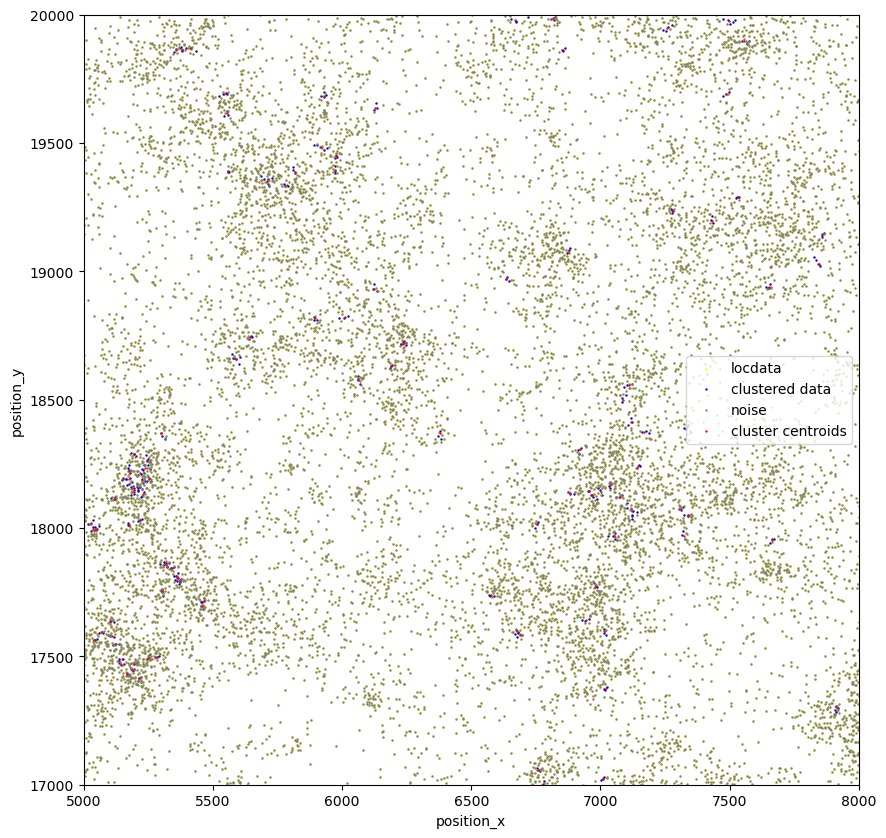

In [80]:
s=0.5
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,10))
me3_locdata.data.plot.scatter(x='position_x', y='position_y', ax=ax, color='Yellow', label='locdata', s=s)
lc.LocData.concat(me3_clusters.references).data.plot.scatter(x='position_x', y='position_y', ax=ax, color='Blue', label='clustered data', s=s)
me3_noise.data.plot.scatter(x='position_x', y='position_y', ax=ax, color='Gray', label='noise', s=s)
me3_clusters.data.plot.scatter(x='position_x', y='position_y', ax=ax, color='Red', label='cluster centroids', s=s)
ax.set_xlim([5000, 8000])
ax.set_ylim([17000, 20000])
plt.show()

In [81]:
me3_locdata.data.groupby("cluster_label")

KeyError: 'cluster_label'